# Week 2, Recap of Week 1 and Matchup Predictions

Part 1 grades the Week 1 predictions against what actually happened.
Part 2 makes the Week 2 predictions as weekly totals (games this week x
per-game expectation).

In [1]:
# Helper functions (loaded from the main branch of the repo)
!rm -f data_pull.py data_pull.py.* scoring.py scoring.py.* stats.py stats.py.* matchup.py matchup.py.*
!wget -q -O data_pull.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/data_pull.py
!wget -q -O scoring.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/scoring.py
!wget -q -O stats.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/stats.py
!wget -q -O matchup.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/matchup.py

# Week 1 predictions CSV (must already be pushed to main)
!mkdir -p predictions
!wget -q -O predictions/week01.csv https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/predictions/week01.csv

from data_pull import get_player_id, get_game_log, get_games_in_window #type: ignore
from scoring import SKATER_FIELD_MAP, GOALIE_FIELD_MAP #type: ignore
from stats import get_player_estimates, get_prior_season_stats, _scored_game_log #type: ignore
from matchup import compare_players, compare_weekly #type: ignore

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# Quick check that the CSV arrived
print(pd.read_csv("predictions/week01.csv").shape)

(32, 11)


In [2]:
# Chart style: two colors (me = blue, opponent = orange), gray for baselines, quiet grid
BLUE, ORANGE, GRAY, INK, MUTED = "#2a78d6", "#eb6834", "#a8a69f", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10,
})

## Config

Date windows are inclusive, per league (YYYY-MM-DD). Set each league to
what Yahoo shows for that week.

In [3]:
SEASON = "20262027"
PRIOR_SEASON = "20252026"

# Inclusive date windows per league. CONFIRM against Yahoo.
WEEK1 = {
    "league_1": ("2026-09-28", "2026-10-04"),
    "league_2": ("2026-09-28", "2026-10-04"),
    "league_3": ("2026-09-28", "2026-10-04"),
}
WEEK2 = {
    "league_1": ("2026-10-05", "2026-10-11"),
    "league_2": ("2026-10-05", "2026-10-11"),
    "league_3": ("2026-10-05", "2026-10-11"),
}

league_scoring = {
    "league_1": {
        "skater": {"G": 2, "A": 1, "PIM": -0.25, "PPG": 0.5, "SHG": 2, "SHA": 1, "GWG": 1, "SOG": 0.1, "HIT": 0.25, "BLK": 0.25},
        "goalie": {"W": 5, "GA": -1, "SV": 0.1, "SHO": 5},
    },
    "league_2": {
        "skater": {"G": 2.5, "A": 1.5, "PIM": -0.25, "PPG": 0.5, "PPA": 0.25, "SHG": 1, "SHA": 0.5, "GWG": 1, "SOG": 0.1, "HIT": 0.4, "BLK": 0.5},
        "goalie": {"W": 5, "GA": -1, "SV": 0.15, "SHO": 5},
    },
    "league_3": {
        "skater": {"G": 2.55, "A": 2.37, "PPP": 1.77, "SHP": 1.73, "GWG": 3.0, "SOG": 0.1, "HIT": 0.2, "BLK": 0.15},
        "goalie": {"W": 3.85, "GA": -0.05, "SV": 0.03, "SHO": 5.75},
    },
}

SLEEPERS_W1 = ["Gabe Perreault", "Chris Kreider", "Bobby McMann"]

# Look each player up once, reuse the id everywhere
_id_cache = {}
def resolve_id(player):
    if isinstance(player, (int, np.integer)):
        return int(player)
    if player not in _id_cache:
        _id_cache[player] = get_player_id(player)
    return _id_cache[player]

def cfg_and_map(league, position):
    side = "goalie" if position == "G" else "skater"
    return league_scoring[league][side], (GOALIE_FIELD_MAP if position == "G" else SKATER_FIELD_MAP)

print("config loaded")

config loaded


# Part 1, How Week 1 went

In [4]:
def window_stats(player, position, league, start, end):
    """Games, total and per-game average fantasy points in a date window, under one league's scoring."""
    pid = resolve_id(player)
    cfg, fmap = cfg_and_map(league, position)
    log = _scored_game_log(pid, SEASON, position, cfg, fmap, force_refresh=True)
    if log is None:
        return {"games": 0, "total": 0.0, "avg": np.nan}
    in_window = log[(log["gameDate"] >= pd.Timestamp(start)) & (log["gameDate"] <= pd.Timestamp(end))]
    n = len(in_window)
    total = float(in_window["fantasy_points"].sum())
    return {"games": n, "total": total, "avg": total / n if n else np.nan}

def outcome(a, b):
    """1 if a beat b, 0 if b beat a, 0.5 for a tie, NaN if either is missing."""
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return 1.0 if a > b else (0.0 if a < b else 0.5)

week1 = pd.read_csv("predictions/week01.csv")
week1_scored = week1[week1["p_me_outperforms"].notna()].copy()

recap_rows = []
for _, row in week1_scored.iterrows():
    start, end = WEEK1[row["league"]]
    me = window_stats(row["me"], row["position"], row["league"], start, end)
    opp = window_stats(row["opponent"], row["position"], row["league"], start, end)
    recap_rows.append({
        **row.to_dict(),
        "me_games": me["games"], "opp_games": opp["games"],
        "me_total": me["total"], "opp_total": opp["total"],
        "me_avg": me["avg"], "opp_avg": opp["avg"],
        "result_avg": outcome(me["avg"], opp["avg"]),
        "result_total": outcome(me["total"] if me["games"] else np.nan,
                                opp["total"] if opp["games"] else np.nan),
    })

recap = pd.DataFrame(recap_rows)

# pick_won: 1 = the model's favored side won, 0 = it lost, 0.5 = tie
fav_me = recap["favored"] == "me"
for kind in ("avg", "total"):
    y = recap[f"result_{kind}"]
    recap[f"pick_won_{kind}"] = np.where(fav_me, y, 1 - y)
    recap[f"brier_{kind}"] = (recap["p_me_outperforms"] - y) ** 2

recap.to_csv("predictions/week01_results.csv", index=False)

print(f"Scored {len(recap)} matchups, {int(recap['result_avg'].isna().sum())} with no result")
print("\nPlayers by games played in the window (check this looks right):")
print(pd.concat([recap["me_games"], recap["opp_games"]]).value_counts().sort_index())

Matched 'Nathan MacKinnon' to 'Nathan MacKinnon'
Pulling fresh game log for 8477492, 20262027
Matched 'Macklin Celebrini' to 'Macklin Celebrini'
Pulling fresh game log for 8484801, 20262027
Matched 'Sebastian Aho' to 'Sebastian Aho'
Pulling fresh game log for 8478427, 20262027
Matched 'Brady Tkachuk' to 'Brady Tkachuk'
Pulling fresh game log for 8480801, 20262027
Matched 'Filip Forsberg' to 'Filip Forsberg'
Pulling fresh game log for 8476887, 20262027
Matched 'Dylan Guenther' to 'Dylan Guenther'
Pulling fresh game log for 8482699, 20262027
Matched 'Tim Stutzle' to 'Tim Stützle'
Pulling fresh game log for 8482116, 20262027
Matched 'Will Smith' to 'Will Smith'
Pulling fresh game log for 8484227, 20262027
Matched 'Matt Boldy' to 'Matt Boldy'
Pulling fresh game log for 8481557, 20262027
Matched 'Martin Necas' to 'Martin Necas'
Pulling fresh game log for 8480039, 20262027
Matched 'Drake Batherson' to 'Drake Batherson'
Pulling fresh game log for 8480208, 20262027
Matched 'Adrian Kempe' to 'A

### Headline numbers

Brier reference: always saying 50% scores 0.250, lower is better. With ~30
picks this is a starting record, not a conclusion.

In [5]:
def summary(df, kind):
    d = df[df[f"result_{kind}"].notna()]
    return {
        "scored": len(d),
        "picks_won": float(d[f"pick_won_{kind}"].sum()),
        "hit_rate": d[f"pick_won_{kind}"].mean(),
        "brier": d[f"brier_{kind}"].mean(),
    }

rows = []
for kind, label in (("avg", "per-game average (closest to what was predicted)"),
                    ("total", "weekly total (what leagues actually score)")):
    rows.append({"scored_as": label, **summary(recap, kind)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nBy league:")
by_league = recap.groupby("league").agg(
    n=("result_avg", "count"),
    hit_rate_avg=("pick_won_avg", "mean"),
    hit_rate_total=("pick_won_total", "mean"),
    brier_avg=("brier_avg", "mean"),
    brier_total=("brier_total", "mean"),
)
print(by_league.to_string(float_format=lambda v: f"{v:.3f}"))

                                       scored_as  scored  picks_won  hit_rate  brier
per-game average (closest to what was predicted)      30     12.000     0.400  0.269
      weekly total (what leagues actually score)      30     11.000     0.367  0.276

By league:
           n  hit_rate_avg  hit_rate_total  brier_avg  brier_total
league                                                            
league_2  13         0.385           0.385      0.268        0.268
league_3  17         0.412           0.353      0.269        0.282


In [6]:
uneven = recap[recap["me_games"] != recap["opp_games"]]
print(len(uneven), "of", len(recap), "matchups have unequal game counts")
print(uneven[["league", "position", "me", "opponent", "me_games", "opp_games",
              "pick_won_avg", "pick_won_total"]].to_string(index=False))

17 of 30 matchups have unequal game counts
  league position                me          opponent  me_games  opp_games  pick_won_avg  pick_won_total
league_2       LW    Filip Forsberg    Dylan Guenther         2          3           0.0             0.0
league_2       LW       Tim Stutzle        Will Smith         1          2           0.0             0.0
league_2       RW   Drake Batherson      Adrian Kempe         1          2           1.0             1.0
league_2        D   Jackson LaCombe      Filip Hronek         2          4           0.0             0.0
league_2        G    Jake Oettinger      Ilya Sorokin         1          2           0.0             0.0
league_3        C   Auston Matthews    Mark Scheifele         3          2           0.0             0.0
league_3        C       Tim Stutzle     Adam Fantilli         1          2           1.0             0.0
league_3       LW    Clayton Keller     Brandon Hagel         3          2           1.0             1.0
league_3    

### Calibration

When the model said 50-55% confident, did the pick win about that often?
With ~30 picks this is mostly noise, it starts the running record.

In [7]:
recap["confidence"] = np.maximum(recap["p_me_outperforms"], 1 - recap["p_me_outperforms"])
bins = [0.5, 0.55, 0.60, 1.0001]
labels = ["50-55%", "55-60%", "60%+"]
recap["conf_bin"] = pd.cut(recap["confidence"], bins=bins, labels=labels, right=False)

def calib(kind):
    d = recap[recap[f"result_{kind}"].notna()]
    return d.groupby("conf_bin", observed=False).agg(
        n=(f"pick_won_{kind}", "size"),
        avg_confidence=("confidence", "mean"),
        actual_hit_rate=(f"pick_won_{kind}", "mean"),
    )

print("Per-game average:")
print(calib("avg").to_string(float_format=lambda v: f"{v:.3f}"))
print("\nWeekly total:")
print(calib("total").to_string(float_format=lambda v: f"{v:.3f}"))

Per-game average:
           n  avg_confidence  actual_hit_rate
conf_bin                                     
50-55%    15           0.523            0.267
55-60%     8           0.569            0.750
60%+       7           0.639            0.286

Weekly total:
           n  avg_confidence  actual_hit_rate
conf_bin                                     
50-55%    15           0.523            0.267
55-60%     8           0.569            0.750
60%+       7           0.639            0.143


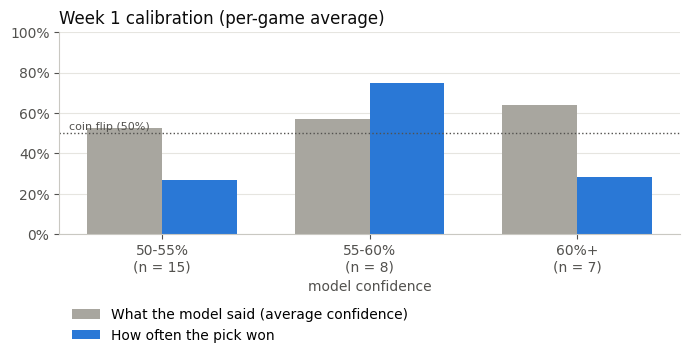

In [8]:
cal = calib("avg").reset_index()
x = np.arange(len(cal))
w = 0.36
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, cal["avg_confidence"], w, color=GRAY, label="What the model said (average confidence)")
ax.bar(x + w/2, cal["actual_hit_rate"], w, color=BLUE, label="How often the pick won")
ax.axhline(0.5, color=MUTED, linewidth=1, linestyle=":")
ax.text(-0.45, 0.515, "coin flip (50%)", color=MUTED, fontsize=8, ha="left")
ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n(n = {n})" for b, n in zip(cal["conf_bin"].astype(str), cal["n"])])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("model confidence")
ax.set_title("Week 1 calibration (per-game average)", loc="left")
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, -0.3), ncol=1)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### Equal-games cut

Only matchups where both players had the same number of games in the window.
This is the fairest check of the per-game probabilities, since game count
can't decide the result.

In [9]:
equal = recap[(recap["me_games"] == recap["opp_games"]) & recap["result_avg"].notna()]
print(f"{len(equal)} of {len(recap)} matchups have equal game counts\n")

print(f"Picks won (per-game average): {equal['pick_won_avg'].sum():.1f} of {len(equal)} ({equal['pick_won_avg'].mean():.1%})")
print(f"Average confidence:           {equal['confidence'].mean():.1%}")
print(f"Brier:                        {equal['brier_avg'].mean():.3f}  (0.250 = coin flip)")

13 of 30 matchups have equal game counts

Picks won (per-game average): 6.0 of 13 (46.2%)
Average confidence:           57.6%
Brier:                        0.267  (0.250 = coin flip)


### My three headline picks

In [10]:
cols = ["league", "position", "me", "opponent", "confidence", "me_games", "opp_games",
        "me_avg", "opp_avg", "me_total", "opp_total", "pick_won_avg", "pick_won_total"]
print(recap[recap["headline_pick"].notna()].sort_values("headline_pick")[cols]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\npick_won: 1 = the pick won, 0 = it lost, 0.5 = tie")

  league position             me        opponent  confidence  me_games  opp_games  me_avg  opp_avg  me_total  opp_total  pick_won_avg  pick_won_total
league_2       LW    Tim Stutzle      Will Smith        0.64         1          2    2.90     4.90      2.90       9.80          0.00            0.00
league_3        C Connor McDavid   Brady Tkachuk        0.63         3          3    9.45     1.22     28.36       3.65          1.00            1.00
league_3       RW Porter Martone Logan Stankoven        0.74         3          3    0.20     1.32      0.60       3.95          0.00            0.00

pick_won: 1 = the pick won, 0 = it lost, 0.5 = tie


### Biggest misses and best calls

In [11]:
d = recap[recap["result_avg"].notna()].copy()
cols = ["league", "position", "me", "opponent", "p_me_outperforms", "confidence",
        "favored", "me_avg", "opp_avg", "me_games", "opp_games"]

print("Biggest misses (largest Brier error, per-game average):")
print(d.sort_values("brier_avg", ascending=False).head(5)[cols]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))

print("\nBest calls (most confident and right):")
right = d[d["pick_won_avg"] == 1].sort_values("confidence", ascending=False)
print(right.head(5)[cols].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Biggest misses (largest Brier error, per-game average):
  league position               me          opponent  p_me_outperforms  confidence  favored  me_avg  opp_avg  me_games  opp_games
league_3       RW   Porter Martone   Logan Stankoven              0.74        0.74       me    0.20     1.32         3          3
league_2       LW      Tim Stutzle        Will Smith              0.64        0.64       me    2.90     4.90         1          2
league_2     UTIL Juraj Slafkovsky      Ivan Demidov              0.63        0.63       me    0.55     2.55         2          2
league_3       RW     Sam Reinhart Alexis Lafreniere              0.61        0.61       me    0.88     1.23         3          4
league_3        D    Thomas Harley    Jake Sanderson              0.40        0.60 opponent    0.35     0.35         2          1

Best calls (most confident and right):
  league position                 me         opponent  p_me_outperforms  confidence  favored  me_avg  opp_avg  me_games  opp

### Every Week 1 matchup, what the model said and what happened

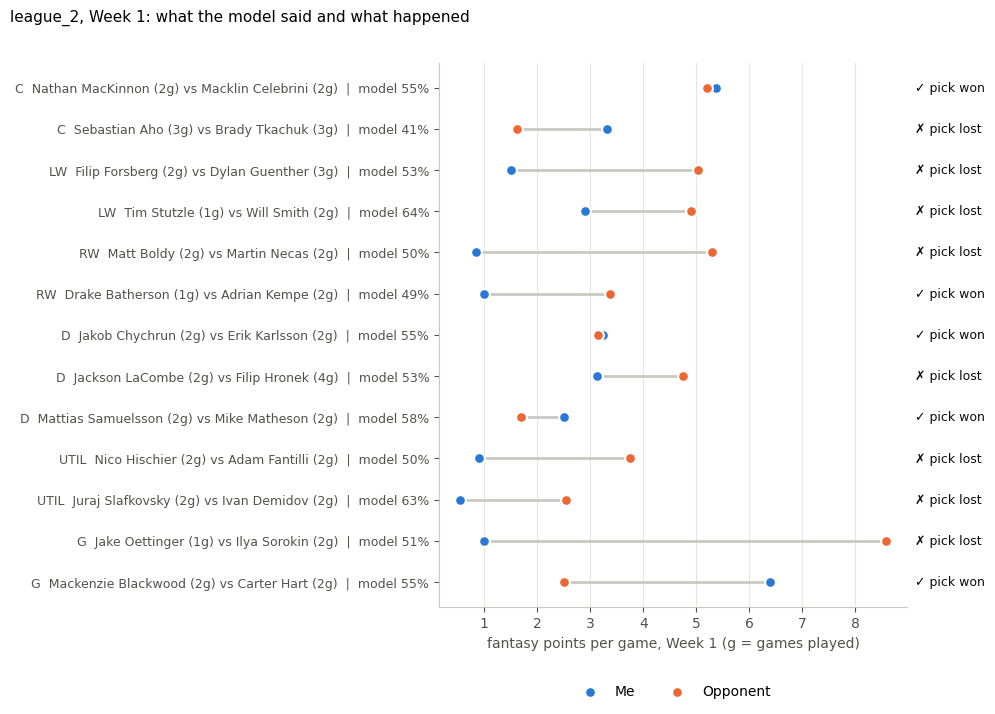

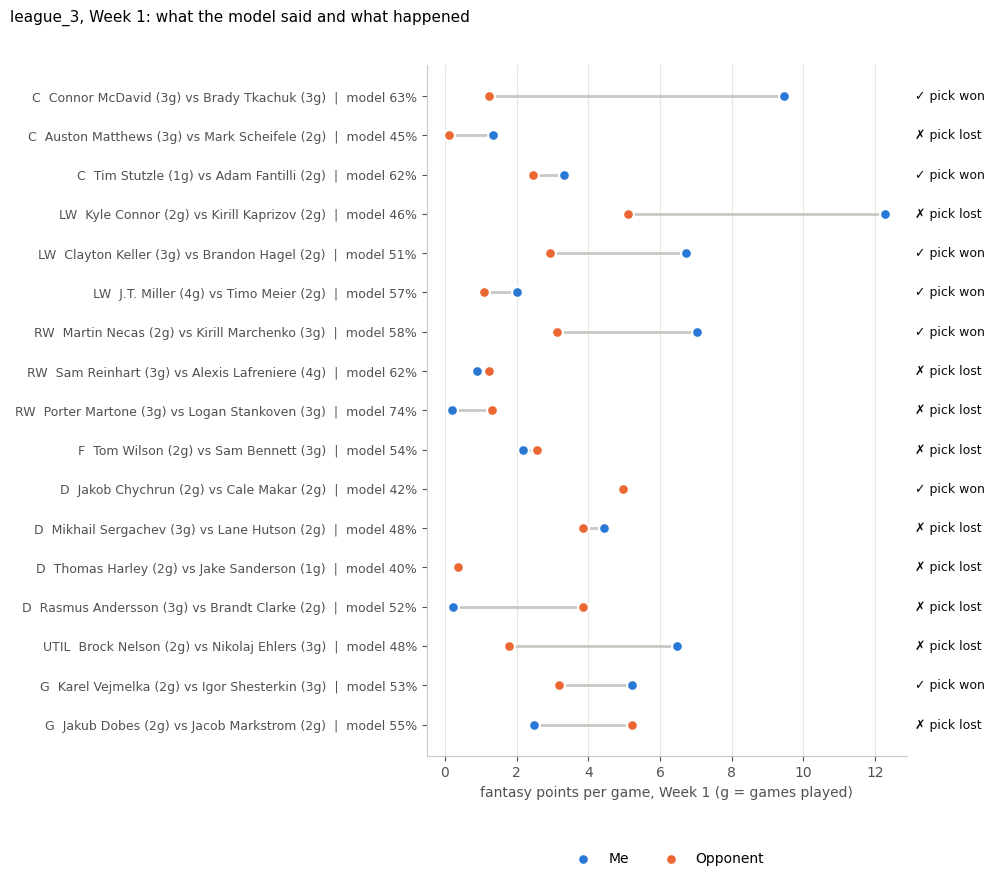

In [12]:
def plot_week1_matchups(league):
    """One row per matchup: where each player actually landed (points per game), with the model's pick on the left."""
    d = recap[(recap["league"] == league) & recap["result_avg"].notna()].reset_index(drop=True)
    y = np.arange(len(d))[::-1]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(d) + 1.8))
    for yi, r in zip(y, d.itertuples()):
        ax.plot([r.me_avg, r.opp_avg], [yi, yi], color="#c9c8c2", linewidth=2, zorder=1)
    ax.scatter(d["me_avg"], y, s=60, color=BLUE, zorder=3, label="Me", edgecolor="white", linewidth=1.5)
    ax.scatter(d["opp_avg"], y, s=60, color=ORANGE, zorder=3, label="Opponent", edgecolor="white", linewidth=1.5)

    labels = [f"{r.position}  {r.me} ({r.me_games}g) vs {r.opponent} ({r.opp_games}g)  |  model {r.p_me_outperforms:.0%}"
              for r in d.itertuples()]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    right = ax.get_xlim()[1]
    for yi, r in zip(y, d.itertuples()):
        mark = "pick won" if r.pick_won_avg == 1 else ("tie" if r.pick_won_avg == 0.5 else "pick lost")
        symbol = "✓" if r.pick_won_avg == 1 else ("=" if r.pick_won_avg == 0.5 else "✗")
        ax.text(right, yi, f"  {symbol} {mark}", va="center", fontsize=9, color=INK, clip_on=False)
    ax.set_xlabel("fantasy points per game, Week 1 (g = games played)")
    fig.suptitle(f"{league}, Week 1: what the model said and what happened", x=0.01, ha="left", fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False, ncol=2)
    ax.grid(axis="y", visible=False)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

for league in sorted(recap["league"].unique()):
    plot_week1_matchups(league)

### Week 1 sleepers, did the thesis show up?

Actual Week 1 points per game against last season's per-game average, under
each league's scoring. One week is a tiny sample, this only starts the tracking.

In [13]:
sleeper_rows = []
for name in SLEEPERS_W1:
    for league in ("league_1", "league_2", "league_3"):
        start, end = WEEK1[league]
        cfg, fmap = cfg_and_map(league, "F")
        w = window_stats(name, "F", league, start, end)
        prior_mu, _ = get_prior_season_stats(resolve_id(name), PRIOR_SEASON, "F", cfg, fmap)
        sleeper_rows.append({
            "player": name, "league": league,
            "week1_games": w["games"], "week1_avg": w["avg"],
            "last_season_avg": prior_mu,
            "vs_last_season": (w["avg"] / prior_mu - 1) if prior_mu and not pd.isna(w["avg"]) else np.nan,
        })

sleepers_recap = pd.DataFrame(sleeper_rows)
print(sleepers_recap.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Matched 'Gabe Perreault' to 'Gabe Perreault'
Pulling fresh game log for 8484210, 20262027
Loading game log for 8484210, 20252026 from cache, 3.3 hours old
Pulling fresh game log for 8484210, 20262027
Loading game log for 8484210, 20252026 from cache, 3.3 hours old
Pulling fresh game log for 8484210, 20262027
Loading game log for 8484210, 20252026 from cache, 3.3 hours old
Matched 'Chris Kreider' to 'Chris Kreider'
Pulling fresh game log for 8475184, 20262027
Loading game log for 8475184, 20252026 from cache, 3.3 hours old
Pulling fresh game log for 8475184, 20262027
Loading game log for 8475184, 20252026 from cache, 3.3 hours old
Pulling fresh game log for 8475184, 20262027
Loading game log for 8475184, 20252026 from cache, 3.3 hours old
Matched 'Bobby McMann' to 'Bobby McMann'
Pulling fresh game log for 8482259, 20262027
Loading game log for 8482259, 20252026 from cache, 3.3 hours old
Pulling fresh game log for 8482259, 20262027
Loading game log for 8482259, 20252026 from cache, 3.3 h

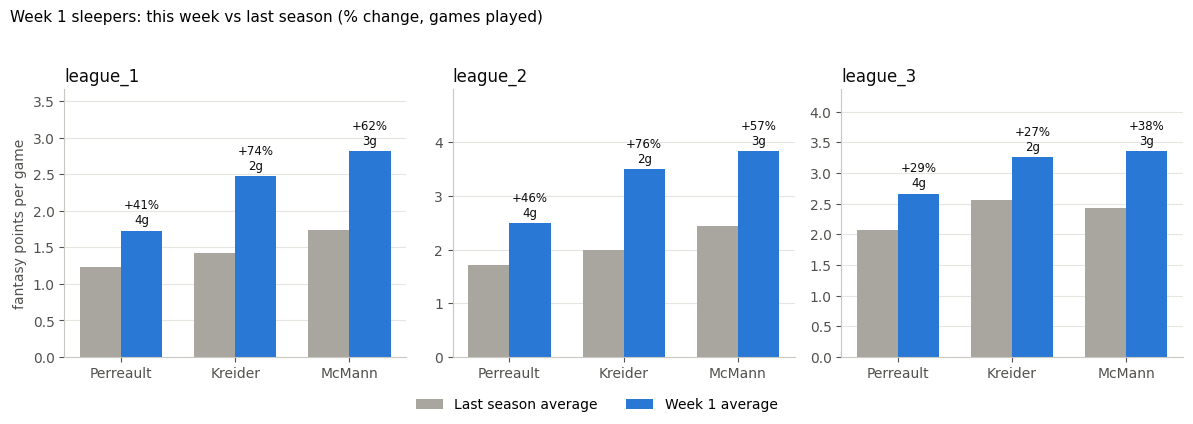

In [14]:
def plot_sleepers(df):
    leagues = sorted(df["league"].unique())
    players = list(dict.fromkeys(df["player"]))
    fig, axes = plt.subplots(1, len(leagues), figsize=(4.0 * len(leagues), 4.2))
    axes = np.atleast_1d(axes)
    x = np.arange(len(players))
    w = 0.36
    for ax, league in zip(axes, leagues):
        d = df[df["league"] == league].set_index("player").loc[players]
        ax.bar(x - w/2, d["last_season_avg"], w, color=GRAY, label="Last season average")
        ax.bar(x + w/2, d["week1_avg"], w, color=BLUE, label="Week 1 average")
        top = max(d["last_season_avg"].max(), d["week1_avg"].max())
        for xi, (_, r) in zip(x, d.iterrows()):
            ax.text(xi + w/2, r["week1_avg"] + top * 0.02, f"{r['vs_last_season']:+.0%}\n{int(r['week1_games'])}g",
                    ha="center", va="bottom", fontsize=8.5, color=INK)
        ax.set_ylim(0, top * 1.3)
        ax.set_xticks(x)
        ax.set_xticklabels([p.split()[-1] for p in players])
        ax.set_title(league, loc="left")
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("fantasy points per game")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
    fig.suptitle("Week 1 sleepers: this week vs last season (% change, games played)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout(rect=(0, 0.06, 1, 0.95))
    plt.show()

plot_sleepers(sleepers_recap)

## What I take from Week 1

**A note on sample size.** Everything below rests on each player's first few
games of the season, 1 to 4 games each. A single game can score close to zero
or well into the double digits, so an average over 2 to 4 games moves a lot
from luck alone. Read this as the start of a record that will only become
informative over many weeks, not as a verdict on the model.

**The record.** Of the 30 comparable matchups, the favored side won 12
(40.0%) scored by per-game average, and 11 (36.7%) scored by weekly total.
Brier scores were 0.269 and 0.276, against 0.250 for always saying 50%. My
average confidence was 56%, which implies about 17 wins, so I came in
under that. With 30 picks it's within normal luck, and not enough to
conclude anything about the model.

**Why the weekly total looked worse.** The Week 1 probabilities were
per-game, with no adjustment for how many games each player's team played.
17 of the 30 matchups had unequal game counts, and in those the favored side
won only 6 by per-game average and 5 by weekly total. Many of those losses
were a player with fewer games than his opponent, which a per-game
probability can't see. On the 13 matchups with equal game counts, the
favored side won 6 (46.2%) against an average confidence of 57.6%, about 7.5
expected wins, which is within normal luck, with a Brier of 0.267.

**Headline picks.** 1 of 3. Connor McDavid over Brady Tkachuk (league 3)
was a clear win, 9.45 per game against 1.22. Tim Stutzle over Will Smith
(league 2) lost on a one-game sample, 2.90 against 4.90 per game. Porter
Martone over Logan Stankoven (league 3, 73.8%, my most confident call) was
my worst miss at 0.20 per game against 1.32. I had flagged Martone as
resting on only 9 games of last-season data. One miss doesn't show the
model is wrong, but it's the kind of call I'll watch closely.

**Pattern to watch.** Higher confidence did not win more often in Week 1: picks
the model rated 50-55% won 4 of 15, 55-60% won 6 of 8, and 60%+ won 2 of 7
(1 of 7 by weekly total). Groups this small swing a lot from luck alone, so
this is a flag, not a finding. The biggest misses were among my most confident
picks, and Martone's was the clearest case of a high number built on thin
data. I'm not changing the model on one week. If confident picks keep missing
over several weeks, a credibility-weighted prior for thin-data players is the
first thing I'd test.

**Sleepers.** All three are up on last season's per-game average in every
league, but on very few games (Perreault 4, McMann 3, Kreider 2):
Perreault +47% / +46% / +29% (leagues 1 / 2 / 3), McMann +75% / +57% / +38%,
Kreider +89% / +76% / +27%. That fits my thesis but doesn't confirm it, and
Kreider's rise is on 2 games. The linemate thesis for Perreault and Kreider
also can't be tested from stat lines alone, it needs the actual line
combinations. I'll track all three, and it only starts to look real if the
rise holds past about 10 games and the lines are what I expected.

**What changes for Week 2.** Predictions are now weekly totals using each
team's real schedule, so a 4-game player against a 3-game player shows up as
an edge. Goalies get a start-share adjustment, since a goalie only plays
some of his team's games. Estimates now include the 2026-27 games played so
far, shrunk toward last season, rather than last season alone.

### Scoreboard block (paste into `SCOREBOARD.md`)

In [15]:
def scoreboard_block():
    s_avg, s_tot = summary(recap, "avg"), summary(recap, "total")
    eq = recap[(recap["me_games"] == recap["opp_games"]) & recap["result_avg"].notna()]
    lines = [
        "**Week 1 results (per-game probabilities, scored two ways)**", "",
        f"- Per-game average: {s_avg['picks_won']:.1f} of {s_avg['scored']} picks won ({s_avg['hit_rate']:.1%}), Brier {s_avg['brier']:.3f}",
        f"- Weekly total: {s_tot['picks_won']:.1f} of {s_tot['scored']} picks won ({s_tot['hit_rate']:.1%}), Brier {s_tot['brier']:.3f}",
        f"- Equal-games matchups only: {eq['pick_won_avg'].sum():.1f} of {len(eq)} won ({eq['pick_won_avg'].mean():.1%}), "
        f"average confidence {eq['confidence'].mean():.1%}, Brier {eq['brier_avg'].mean():.3f}",
        "", "| Confidence | n | Avg confidence | Actual hit rate |", "|---|---|---|---|",
    ]
    for label, r in calib("avg").iterrows():
        hit = f"{r['actual_hit_rate']:.1%}" if r["n"] else "n/a"
        conf = f"{r['avg_confidence']:.1%}" if r["n"] else "n/a"
        lines.append(f"| {label} | {int(r['n'])} | {conf} | {hit} |")
    lines += ["", "Brier reference: 0.250 = always saying 50%. n is far too small to conclude anything, "
                  "and Week 1 had no game-count adjustment (17 of 30 matchups had unequal games)."]
    return "\n".join(lines)

print(scoreboard_block())

**Week 1 results (per-game probabilities, scored two ways)**

- Per-game average: 12.0 of 30 picks won (40.0%), Brier 0.269
- Weekly total: 11.0 of 30 picks won (36.7%), Brier 0.276
- Equal-games matchups only: 6.0 of 13 won (46.2%), average confidence 57.6%, Brier 0.267

| Confidence | n | Avg confidence | Actual hit rate |
|---|---|---|---|
| 50-55% | 15 | 52.3% | 26.7% |
| 55-60% | 8 | 56.9% | 75.0% |
| 60%+ | 7 | 63.9% | 28.6% |

Brier reference: 0.250 = always saying 50%. n is far too small to conclude anything, and Week 1 had no game-count adjustment (17 of 30 matchups had unequal games).


# Part 2, Week 2 predictions

In [16]:
matchups_w2 = {
        "league_1": [
        {"position": "C", "me": "Connor McDavid", "opponent": "Mark Scheifele"},
        {"position": "C", "me": "Tim Stutzle", "opponent": "Nick Suzuki"},
        {"position": "LW", "me": "Filip Forsberg", "opponent": "Dylan Guenther"},
        {"position": "LW", "me": "Kyle Connor", "opponent": "Will Smith"},
        {"position": "RW", "me": "Brad Marchand", "opponent": "Ivan Demidov"},
        {"position": "RW", "me": "Alex Tuch", "opponent": "Kirill Marchenko"},
        {"position": "D", "me": "Jakob Chychrun", "opponent": "Cole Hutson"},
        {"position": "D", "me": "Mackenzie Weegar", "opponent": "John Carlson"},
        {"position": "D", "me": "Thomas Harley", "opponent": "Brandon Montour"},
        {"position": "D", "me": "Mattias Samuelsson", "opponent": "Erik Karlsson"},
        {"position": "UTIL", "me": "Elias Pettersson", "opponent": "Quinn Hughes"},
        {"position": "G", "me": "Jeremy Swayman", "opponent": "Spencer Knight"},
        {"position": "G", "me": "Jake Oettinger", "opponent": "Joel Hofer"},
    ],
    "league_2": [
        {"position": "C", "me": "Nathan MacKinnon", "opponent": "Roope Hintz"},
        {"position": "C", "me": "Sebastian Aho", "opponent": "Joel Eriksson Ek"},
        {"position": "LW", "me": "Filip Forsberg", "opponent": "Jason Robertson"},
        {"position": "LW", "me": "Tim Stutzle", "opponent": "Pavel Dorofeyev"},
        {"position": "RW", "me": "Matt Boldy", "opponent": "David Pastrnak"},
        {"position": "RW", "me": "Drake Batherson", "opponent": "Kirill Marchenko"},
        {"position": "D", "me": "Jakob Chychrun", "opponent": "Cole Hutson"},
        {"position": "D", "me": "Jackson LaCombe", "opponent": "John Carlson"},
        {"position": "D", "me": "Mattias Samuelsson", "opponent": "Brandon Montour"},
        # Charlie McAvoy is suspended for the season's first 6 games,
        # and my opponent only carries 3 defensemen this week anyway,
        # so this slot has no real comparison to make
        {"position": "D", "me": "Charlie McAvoy (suspended, first 6 games)", "opponent": "Sean Walker"},
        {"position": "UTIL", "me": "Nico Hischier", "opponent": "Alex Laferriere"},
        {"position": "UTIL", "me": "Juraj Slafkovsky", "opponent": "Gabriel Vilardi"},
        {"position": "G", "me": "Jake Oettinger", "opponent": "Dan Vladar"},
        {"position": "G", "me": "Mackenzie Blackwood", "opponent": "Logan Thompson"},
    ],

    "league_3": [
        {"position": "C", "me": "Connor McDavid", "opponent": "Nico Hischier"},
        {"position": "C", "me": "Auston Matthews", "opponent": "Ryan O'Reilly"},
        {"position": "C", "me": "Tim Stutzle", "opponent": "Marco Rossi"},
        {"position": "LW", "me": "Kyle Connor", "opponent": "Matt Boldy"},
        {"position": "LW", "me": "Clayton Keller", "opponent": "Filip Forsberg"},
        {"position": "LW", "me": "J.T. Miller", "opponent": "Dylan Holloway"},
        {"position": "RW", "me": "Martin Necas", "opponent": "Nikita Kucherov"},
        {"position": "RW", "me": "Sam Reinhart", "opponent": "Jesper Bratt"},
        {"position": "RW", "me": "Porter Martone", "opponent": "Mitch Marner"},
        {"position": "F", "me": "Alex Ovechkin", "opponent": "JJ Peterka"},
        {"position": "F", "me": "Tom Wilson", "opponent": "Jimmy Snuggerud"},
        {"position": "D", "me": "Jakob Chychrun", "opponent": "Zach Werenski"},
        {"position": "D", "me": "Mikhail Sergachev", "opponent": "Rasmus Dahlin"},
        {"position": "D", "me": "Thomas Harley", "opponent": "Erik Karlsson"},
        {"position": "D", "me": "Rasmus Andersson", "opponent": "Filip Hronek"},
        {"position": "UTIL", "me": "Brock Nelson", "opponent": "Adrian Kempe"},
        {"position": "G", "me": "Karel Vejmelka", "opponent": "Jesper Wallstedt"},
        {"position": "G", "me": "Jakub Dobes", "opponent": "Jeremy Swayman"},
    ],
}

# Only if the automatic team lookup gets someone wrong, name -> team abbreviation
TEAM_OVERRIDES = {
    # "Some Player": "TOR",
}

# Only to override the automatic goalie start-share, name -> share of team games he starts (0 to 1)
GOALIE_START_SHARE = {
    # "Jake Oettinger": 0.6,
}

In [17]:
def current_team(player):
    """Most recent team from the game log, this season first, then last season. Returns (team, source)."""
    if player in TEAM_OVERRIDES:
        return TEAM_OVERRIDES[player], "override"
    pid = resolve_id(player)
    for season, source in ((SEASON, "this season"), (PRIOR_SEASON, "last season, VERIFY")):
        log = get_game_log(pid, season=season)
        if not log.empty and "teamAbbrev" in log.columns:
            return log.sort_values("gameDate").iloc[-1]["teamAbbrev"], source
    return None, "not found"

def goalie_start_share(player):
    """Share of his team's games a goalie starts, from last season's starts out of 82, unless overridden."""
    if player in GOALIE_START_SHARE:
        return GOALIE_START_SHARE[player]
    log = get_game_log(resolve_id(player), season=PRIOR_SEASON)
    if log.empty or len(log) < 20 or "gamesStarted" not in log.columns:
        return 0.5
    starts = pd.to_numeric(log["gamesStarted"], errors="coerce").fillna(0).sum()
    return float(min(max(starts / 82, 0.15), 0.95))

def is_placeholder(value):
    return isinstance(value, str) and (value.startswith("None") or "suspended" in value.lower())

def run_weekly_comparisons(league):
    start, end = WEEK2[league]
    results = []
    for m in matchups_w2[league]:
        pos = m["position"]
        base = {"week": 2, "league": league, "position": pos, "me": m["me"], "opponent": m["opponent"]}

        if is_placeholder(m["me"]) or is_placeholder(m["opponent"]):
            results.append({**base, "note": "no real comparison in this slot"})
            continue

        cfg, fmap = cfg_and_map(league, pos)
        me_id, opp_id = resolve_id(m["me"]), resolve_id(m["opponent"])
        me_est = get_player_estimates(me_id, pos, cfg, fmap, season=SEASON, prior_season=PRIOR_SEASON)
        opp_est = get_player_estimates(opp_id, pos, cfg, fmap, season=SEASON, prior_season=PRIOR_SEASON)
        if me_est is None or opp_est is None:
            results.append({**base, "note": f"skipped (no data: me={me_est is not None}, opp={opp_est is not None})"})
            continue

        me_team, me_src = current_team(m["me"])
        opp_team, opp_src = current_team(m["opponent"])
        if me_team is None or opp_team is None:
            results.append({**base, "note": "skipped (could not find a team, add a TEAM_OVERRIDES entry)"})
            continue

        me_games = len(get_games_in_window(me_team, start, end))
        opp_games = len(get_games_in_window(opp_team, start, end))
        me_share = goalie_start_share(m["me"]) if pos == "G" else 1.0
        opp_share = goalie_start_share(m["opponent"]) if pos == "G" else 1.0

        kwargs = dict(label_a=str(m["me"]), label_b=str(m["opponent"]), start_share_a=me_share, start_share_b=opp_share)
        weekly = compare_weekly(me_est, me_games, opp_est, opp_games, use="season", **kwargs)
        weekly_recent = compare_weekly(me_est, me_games, opp_est, opp_games, use="recent", **kwargs)
        per_game = compare_players(me_est, opp_est, str(m["me"]), str(m["opponent"]))

        p = weekly["probability_a_outperforms_b"]
        notes = []
        if "VERIFY" in me_src or "VERIFY" in opp_src:
            notes.append("team taken from last season, verify")
        if me_games == 0 or opp_games == 0:
            notes.append("a player has no games this week")
        results.append({
            **base,
            "me_team": me_team, "opp_team": opp_team,
            "me_games": me_games, "opp_games": opp_games,
            "me_start_share": me_share if pos == "G" else np.nan,
            "opp_start_share": opp_share if pos == "G" else np.nan,
            "me_week_mu": weekly["mu_a"], "opp_week_mu": weekly["mu_b"],
            "me_week_sigma": weekly["sigma_a"], "opp_week_sigma": weekly["sigma_b"],
            "p_me_outperforms": p,
            "confidence": max(p, 1 - p),
            "favored": "me" if p > 0.5 else ("opponent" if p < 0.5 else "even"),
            "p_per_game": per_game["probability_a_outperforms_b"],
            "p_recent_form": weekly_recent["probability_a_outperforms_b"],
            "me_games_so_far": me_est["games_played"], "opp_games_so_far": opp_est["games_played"],
            "low_confidence": bool(me_est["low_confidence"] or opp_est["low_confidence"]),
            "prediction_unit": "weekly_total",
            "headline_pick": np.nan,
            "note": "; ".join(notes),
        })
    return pd.DataFrame(results)

active = [lg for lg, ms in matchups_w2.items() if ms]
print("Leagues with matchups:", active or "none yet, paste matchups above and re-run")
week2_results = {lg: run_weekly_comparisons(lg) for lg in active}

Leagues with matchups: ['league_1', 'league_2', 'league_3']
Loading game log for 8478402, 20262027 from cache, 0.0 hours old
Loading game log for 8478402, 20252026 from cache, 2.4 hours old
Loading game log for 8476460, 20262027 from cache, 0.0 hours old
Loading game log for 8476460, 20252026 from cache, 2.4 hours old
Loading game log for 8478402, 20262027 from cache, 0.0 hours old
Loading game log for 8476460, 20262027 from cache, 0.0 hours old
Matched 'Nick Suzuki' to 'Nick Suzuki'
Loading game log for 8482116, 20262027 from cache, 0.0 hours old
Loading game log for 8482116, 20252026 from cache, 2.4 hours old
Loading game log for 8480018, 20262027 from cache, 2.4 hours old
Loading game log for 8480018, 20252026 from cache, 2.4 hours old
Loading game log for 8482116, 20262027 from cache, 0.0 hours old
Loading game log for 8480018, 20262027 from cache, 2.4 hours old
Loading game log for 8476887, 20262027 from cache, 0.0 hours old
Loading game log for 8476887, 20252026 from cache, 2.3 h

In [18]:
all_w2 = pd.concat(week2_results.values(), ignore_index=True)
show = ["position", "me", "opponent", "me_games", "opp_games", "me_week_mu", "opp_week_mu",
        "p_me_outperforms", "p_per_game", "p_recent_form", "low_confidence", "note"]
for league, df in week2_results.items():
    print(f"\n=== {league.upper()} ===")
    d = df.copy()
    for c in ("p_me_outperforms", "p_per_game", "p_recent_form"):
        if c in d:
            d[c] = d[c].map(lambda p: f"{p:.1%}" if pd.notna(p) else "n/a")
    print(d[[c for c in show if c in d.columns]].to_string(index=False, float_format=lambda v: f"{v:.1f}"))

print()
for league, df in week2_results.items():
    d = df[df["p_me_outperforms"].notna()]
    if d.empty:
        continue
    print(f"{league}: favored in {int((d['favored'] == 'me').sum())} of {len(d)} comparable slots, "
          f"{d['p_me_outperforms'].mean():.1%} average win probability across slots")
    for r in d[(d["p_me_outperforms"] - 0.5).abs() < 0.02].itertuples():
        print(f"   coin flip: {r.me} vs {r.opponent} ({r.p_me_outperforms:.1%})")
    for r in d[d["me_games"] != d["opp_games"]].itertuples():
        print(f"   unequal games: {r.me} {r.me_games:.0f} vs {r.opponent} {r.opp_games:.0f}")
    for r in df[df["p_me_outperforms"].isna()].itertuples():
        print(f"   {r.me} vs {r.opponent}: {r.note}")


=== LEAGUE_1 ===
position                 me         opponent  me_games  opp_games  me_week_mu  opp_week_mu p_me_outperforms p_per_game p_recent_form  low_confidence note
       C     Connor McDavid   Mark Scheifele         2          3         6.7          5.4            61.1%      69.6%         73.4%           False     
       C        Tim Stutzle      Nick Suzuki         4          3         8.9          7.4            62.1%      46.6%         52.7%           False     
      LW     Filip Forsberg   Dylan Guenther         3          3         6.0          7.6            37.0%      42.4%         35.2%           False     
      LW        Kyle Connor       Will Smith         3          3         8.7          6.2            67.8%      60.5%         71.4%           False     
      RW      Brad Marchand     Ivan Demidov         2          3         4.1          4.2            49.6%      61.3%         33.9%           False     
      RW          Alex Tuch Kirill Marchenko         3    

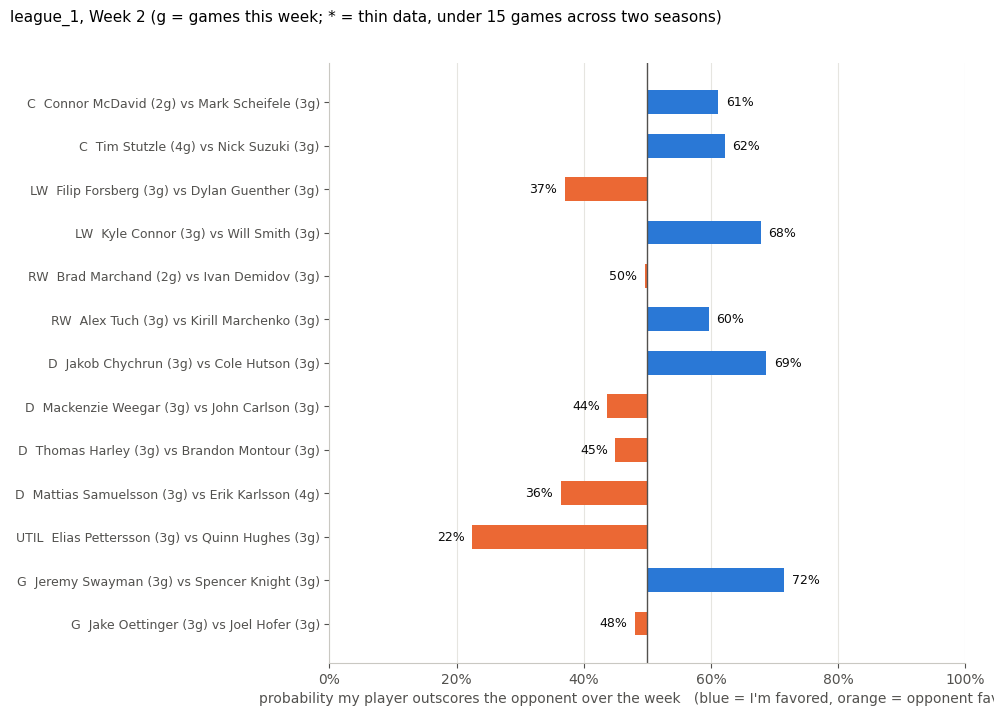

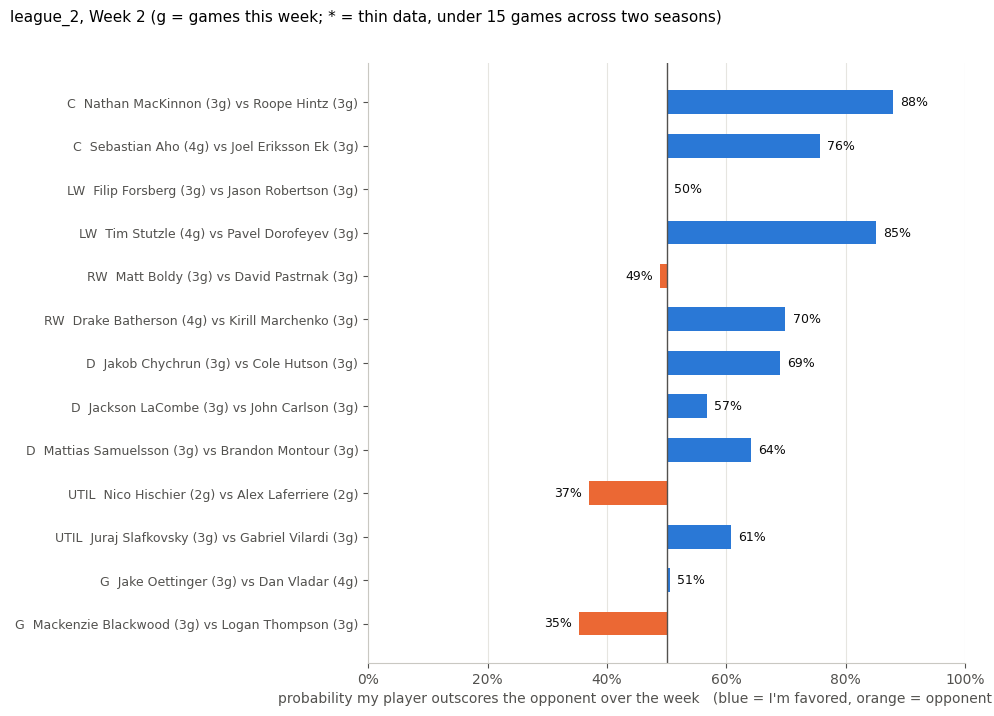

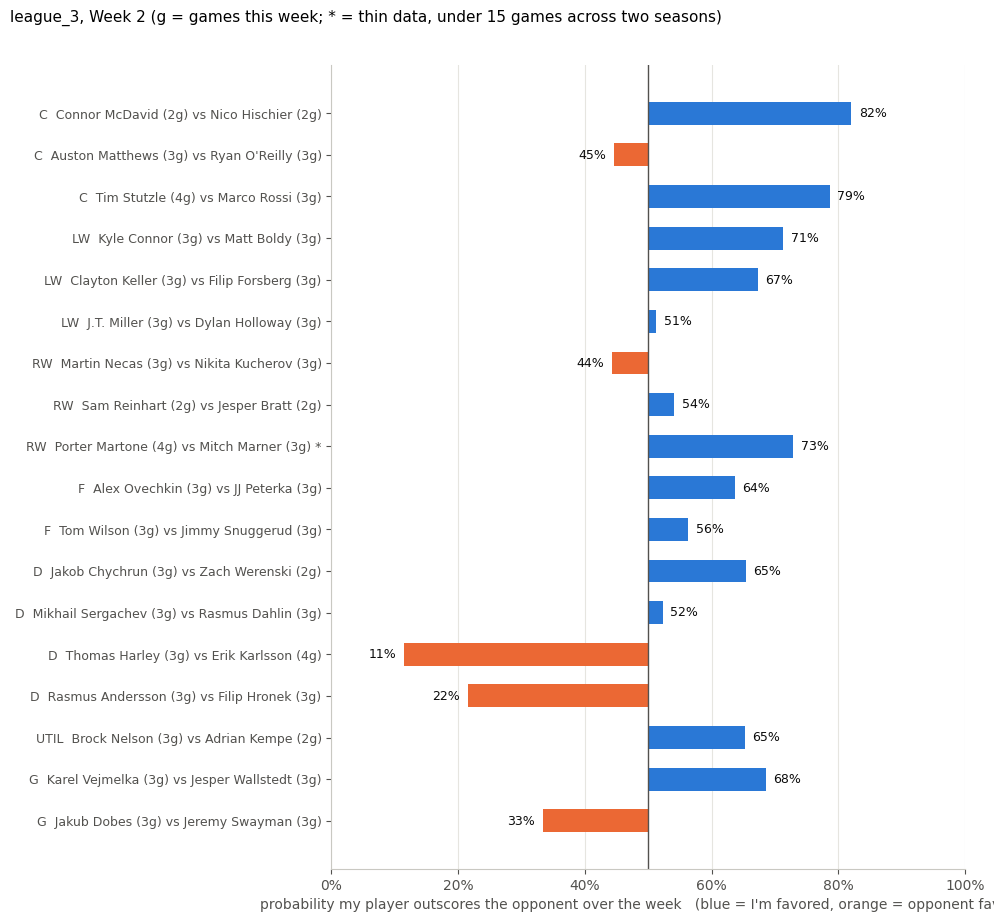

In [19]:
def plot_week2_bars(league, df):
    d = df[df["p_me_outperforms"].notna()].reset_index(drop=True)
    if d.empty:
        return
    y = np.arange(len(d))[::-1]
    colors = np.where(d["p_me_outperforms"] >= 0.5, BLUE, ORANGE)
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(d) + 1.8))
    ax.barh(y, d["p_me_outperforms"] - 0.5, left=0.5, color=colors, height=0.55)
    ax.axvline(0.5, color=MUTED, linewidth=1)
    star = np.where(d["low_confidence"].astype(bool), " *", "")
    labels = [f"{r.position}  {r.me} ({r.me_games:.0f}g) vs {r.opponent} ({r.opp_games:.0f}g){s}"
              for r, s in zip(d.itertuples(), star)]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    for yi, p in zip(y, d["p_me_outperforms"]):
        ax.text(p + (0.012 if p >= 0.5 else -0.012), yi, f"{p:.0%}", va="center",
                ha="left" if p >= 0.5 else "right", fontsize=9, color=INK)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_xlabel("probability my player outscores the opponent over the week   (blue = I'm favored, orange = opponent favored)")
    fig.suptitle(f"{league}, Week 2 (g = games this week; * = thin data, under 15 games across two seasons)",
                 x=0.01, ha="left", fontsize=11)
    ax.grid(axis="y", visible=False)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

for league, df in week2_results.items():
    plot_week2_bars(league, df)

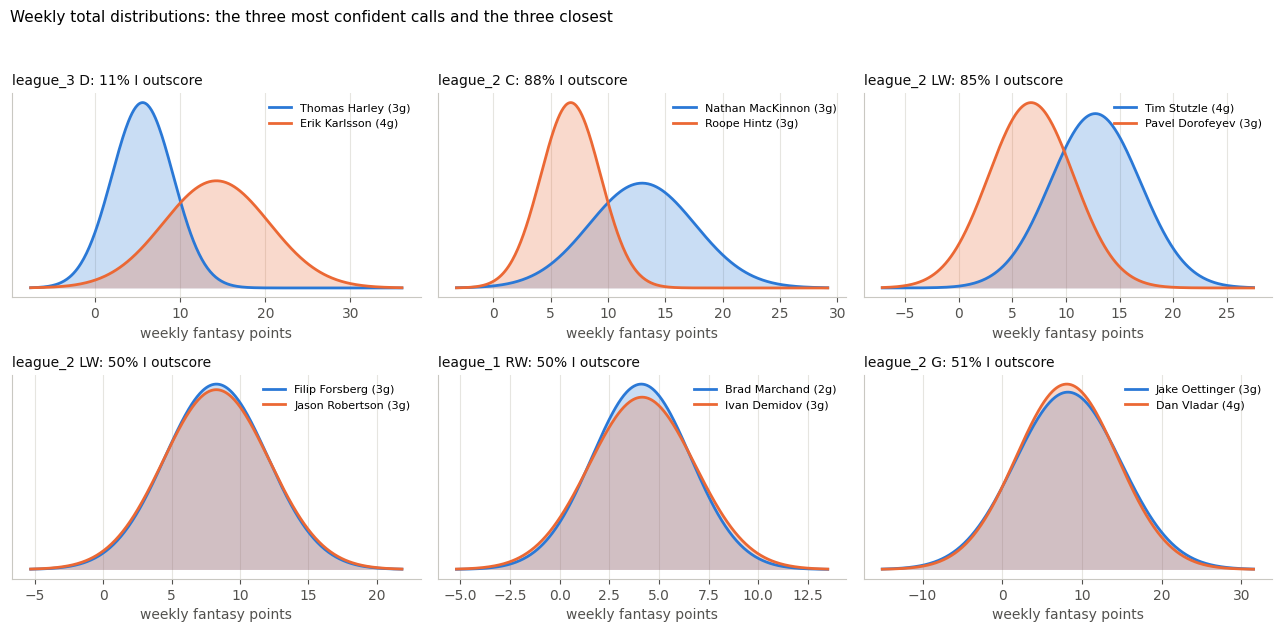

In [20]:
def plot_week2_distributions(all_df, n_each=3):
    ok = all_df[all_df["p_me_outperforms"].notna()]
    firm = ok.sort_values("confidence", ascending=False).head(n_each)
    close = ok.assign(gap=(ok["p_me_outperforms"] - 0.5).abs()).sort_values("gap").head(n_each)
    chosen = pd.concat([firm, close]).drop_duplicates(subset=["league", "me", "opponent"])
    n = len(chosen)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.3 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, chosen.iterrows()):
        lo = min(r["me_week_mu"] - 3.5 * r["me_week_sigma"], r["opp_week_mu"] - 3.5 * r["opp_week_sigma"])
        hi = max(r["me_week_mu"] + 3.5 * r["me_week_sigma"], r["opp_week_mu"] + 3.5 * r["opp_week_sigma"])
        x = np.linspace(lo, hi, 400)
        ax.fill_between(x, norm.pdf(x, r["me_week_mu"], r["me_week_sigma"]), color=BLUE, alpha=0.25, linewidth=0)
        ax.plot(x, norm.pdf(x, r["me_week_mu"], r["me_week_sigma"]), color=BLUE, linewidth=2, label=f"{r['me']} ({r['me_games']:.0f}g)")
        ax.fill_between(x, norm.pdf(x, r["opp_week_mu"], r["opp_week_sigma"]), color=ORANGE, alpha=0.25, linewidth=0)
        ax.plot(x, norm.pdf(x, r["opp_week_mu"], r["opp_week_sigma"]), color=ORANGE, linewidth=2, label=f"{r['opponent']} ({r['opp_games']:.0f}g)")
        ax.set_title(f"{r['league']} {r['position']}: {r['p_me_outperforms']:.0%} I outscore", loc="left", fontsize=10)
        ax.set_yticks([])
        ax.set_xlabel("weekly fantasy points")
        ax.legend(frameon=False, fontsize=8, loc="upper right")
        ax.grid(axis="y", visible=False)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Weekly total distributions: the three most confident calls and the three closest", x=0.01, ha="left", fontsize=11)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

plot_week2_distributions(all_w2)

In [21]:
g = all_w2[(all_w2["position"] == "G") & all_w2["p_me_outperforms"].notna()].copy()
g["me_exp_starts"] = g["me_games"] * g["me_start_share"]
g["opp_exp_starts"] = g["opp_games"] * g["opp_start_share"]
cols = ["league", "me", "opponent", "me_games", "me_start_share", "me_exp_starts",
        "opp_games", "opp_start_share", "opp_exp_starts",
        "me_week_mu", "opp_week_mu", "p_me_outperforms", "p_per_game"]
print(g[cols].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

  league                  me         opponent  me_games  me_start_share  me_exp_starts  opp_games  opp_start_share  opp_exp_starts  me_week_mu  opp_week_mu  p_me_outperforms  p_per_game
league_1      Jeremy Swayman   Spencer Knight      3.00            0.66           1.98       3.00             0.67            2.01        7.70         2.58              0.72        0.67
league_1      Jake Oettinger       Joel Hofer      3.00            0.66           1.98       3.00             0.52            1.57        6.00         6.44              0.48        0.43
league_2      Jake Oettinger       Dan Vladar      3.00            0.66           1.98       4.00             0.62            2.49        8.23         8.09              0.51        0.57
league_2 Mackenzie Blackwood   Logan Thompson      3.00            0.44           1.32       3.00             0.71            2.12        6.21         9.86              0.35        0.50
league_3      Karel Vejmelka Jesper Wallstedt      3.00            0.7

In [22]:
HEADLINE_PICKS = [
    ("league_2", "Nathan MacKinnon"),
    ("league_3", "Connor McDavid"),
    ("league_1", "Jeremy Swayman"),
]

out = pd.concat(week2_results.values(), ignore_index=True)
for i, (league, player) in enumerate(HEADLINE_PICKS, start=1):
    out.loc[(out["league"] == league) & (out["me"] == player), "headline_pick"] = i
out["source"] = "generated by week02_matchup_calls.ipynb"
out.to_csv("predictions/week02.csv", index=False)
print(f"Saved {len(out)} rows, {int(out['headline_pick'].notna().sum())} headline picks")

from google.colab import files  # type: ignore
files.download("predictions/week02.csv")

Saved 45 rows, 3 headline picks


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Analysis of this week's calls

**A note on the numbers.** These are weekly-total probabilities from the
season-level estimates (last season blended with this season's games so far).
The model doesn't know about injuries, line changes or opponent strength, and
it treats a week's total as a normal curve, which hockey isn't exactly. Even a
correct 70% call loses 3 times in 10, so I'd expect some of these to miss.

### My three headline picks

Taken together, these probabilities imply about 2.4 wins out of 3, and all
three winning is roughly a coin flip (about 51%, treating them as independent).

1. **Nathan MacKinnon over Roope Hintz (league 2, 87.9%).** The strongest call
   of the week and not driven by schedule. Both play 3 games, MacKinnon is
   projected for 13.0 points against 6.8, and the per-game probability is
   already 75%.
2. **Connor McDavid over Nico Hischier (league 3, 82.0%).** Again equal games
   (2 each), 13.6 projected points against 5.5, and a 74% per-game edge. With
   only 2 games each there's more room for a bad night to matter, so I'm
   treating the 82% with a bit more caution than the sample size suggests.
3. **Jeremy Swayman over Spencer Knight (league 1, 71.5%), my goalie call.**
   Both goalies are expected to start about 2 of 3 games (66% and 67% start
   share), so the 7.7 to 2.6 gap is about how they play per start, not how
   often they play. The catch is that Swayman is also my opponent's goalie
   against Jakub Dobes in league 3 (33%), so this is partly a hedge, a good
   Swayman week helps in one league and hurts in the other.

### The close ones

These are within about 2 points of a coin flip, and I'd decide them on
lineup news, not on the model.

- **Brad Marchand vs Ivan Demidov (league 1, 49.6%).** The signals conflict:
  Marchand is ahead per game (61%) but plays 2 games to Demidov's 3, and his
  recent form points the other way (34%).
- **Jake Oettinger vs Joel Hofer (league 1, 48.1%)** and **vs Dan Vladar
  (league 2, 50.6%).** Oettinger is in two leagues, so these two results will
  move together. Against Vladar the per-game edge (57%) is cancelled out by
  Vladar's 4 games to Oettinger's 3.
- **Filip Forsberg vs Jason Robertson (league 2, 50.1%)**, **Matt Boldy vs
  David Pastrnak (league 2, 48.9%)** and **J.T. Miller vs Dylan Holloway
  (league 3, 51.3%)**, all essentially equal projections (8.3 against 8.3,
  8.9 against 9.1, 8.7 against 8.5). Boldy's and Forsberg's recent form leans
  slightly my way (56%), Miller's leans the other way (43%).

### Where I'm most likely to be outperformed

- **Thomas Harley vs Erik Karlsson (league 3, 11.5%).** The most lopsided call
  of the week against me: 5.6 projected points against 14.3. Part of it is
  that Karlsson plays 4 games to Harley's 3, and part is league 3's heavy
  weighting of power-play points, which favours a power-play defenseman. The
  per-game number (32.5%) is much less extreme, so the weekly gap leans on
  that extra game.
- **Rasmus Andersson vs Filip Hronek (league 3, 21.5%)** and **Elias
  Pettersson vs Quinn Hughes (league 1, 22.5%).** Both have equal games, so
  these are genuine per-game gaps (about 32% and 33% per game), not schedule
  effects.
- **Jakub Dobes vs Jeremy Swayman (league 3, 33.4%).** The other side of my
  Swayman call.
- **Mackenzie Blackwood vs Logan Thompson (league 2, 35.4%).** This is mostly
  workload: Blackwood is expected to start about 1.3 games against Thompson's
  2.1, and the per-game probability is 50.5%. If Blackwood gets more starts
  than the model assumes, this gap closes.
- **Mattias Samuelsson vs Erik Karlsson (league 1, 36.4%).** Also schedule
  driven, since Karlsson has 4 games to 3 and the per-game probability is
  52%.
- **Nico Hischier vs Alex Laferriere (league 2, 37.0%)** and **Filip Forsberg
  vs Dylan Guenther (league 1, 37.0%).** Modest underdogs, both with equal
  games.

Worth noting: Auston Matthews (league 3, 44.6%) and Martin Necas (44.3%) are
both slight underdogs, and Necas's recent form (67%) disagrees with the
season-level number, so I'm watching those.

# Sleeper Picks for this Week

In [23]:
from stats import build_full_skater_log  #type: ignore

SLEEPERS_W2 = ["Paul Cotter", "Eli Tolvanen", "Tommy Novak"]

def toi_minutes(value):
    """'17:46' -> 17.77 minutes, anything unreadable -> NaN."""
    try:
        m, s = str(value).split(":")
        return int(m) + int(s) / 60
    except Exception:
        return np.nan

def process_row(name, season):
    log = build_full_skater_log(resolve_id(name), season, include_hits_blocks=False)
    if log.empty:
        return None
    shots, goals = log["shots"].sum(), log["goals"].sum()
    return {
        "games": len(log),
        "pts_per_game": log["points"].mean(),
        "shots_per_game": log["shots"].mean(),
        "shooting_pct": goals / shots if shots else np.nan,
        "pp_points": log["powerPlayPoints"].sum(),
        "toi_per_game": log["toi"].map(toi_minutes).mean() if "toi" in log.columns else np.nan,
    }

proc = []
for name in SLEEPERS_W2:
    for season, label in ((SEASON, "this season"), (PRIOR_SEASON, "last season")):
        r = process_row(name, season)
        if r:
            proc.append({"player": name, "season": label, **r})
process = pd.DataFrame(proc)
print(process.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\nA hot start built on shots and ice time tends to last. One built on a high shooting % usually doesn't.")

Matched 'Paul Cotter' to 'Paul Cotter'
Loading game log for 8481032, 20262027 from cache, 0.2 hours old
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Matched 'Eli Tolvanen' to 'Eeli Tolvanen'
Loading game log for 8480009, 20262027 from cache, 0.2 hours old
Loading game log for 8480009, 20252026 from cache, 0.2 hours old
Matched 'Tommy Novak' to 'Tommy Novak'
Loading game log for 8478438, 20262027 from cache, 0.2 hours old
Loading game log for 8478438, 20252026 from cache, 0.2 hours old
      player      season  games  pts_per_game  shots_per_game  shooting_pct  pp_points  toi_per_game
 Paul Cotter this season      4          1.50            1.75          0.57          1         15.22
 Paul Cotter last season     79          0.19            0.77          0.15          1         10.68
Eli Tolvanen this season      4          0.75            1.50          0.50          0         13.48
Eli Tolvanen last season     78          0.46            1.81          0.09         14

In [24]:
SEASON_START, TODAY = "2026-09-01", "2026-10-05"

rows = []
for name in SLEEPERS_W2:
    pid = resolve_id(name)
    for league in ("league_1", "league_2", "league_3"):
        cfg, fmap = cfg_and_map(league, "F")
        now = window_stats(name, "F", league, SEASON_START, TODAY)
        prior_mu, _ = get_prior_season_stats(pid, PRIOR_SEASON, "F", cfg, fmap)
        est = get_player_estimates(pid, "F", cfg, fmap, season=SEASON, prior_season=PRIOR_SEASON)
        rows.append({
            "player": name, "league": league, "games": now["games"],
            "this_season_avg": now["avg"], "last_season_avg": prior_mu,
            "vs_last_season": (now["avg"] / prior_mu - 1) if prior_mu and not pd.isna(now["avg"]) else np.nan,
            "season_mu": est["season_mu"] if est else np.nan,
            "recent_mu": est["recent_mu"] if est else np.nan,
            "low_confidence": est["low_confidence"] if est else np.nan,
        })
sleepers_w2 = pd.DataFrame(rows)
print(sleepers_w2.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\nseason_mu = this season's games blended toward last season (the number the predictions use)")
print("recent_mu = recent form, running across last season into this one")

Pulling fresh game log for 8481032, 20262027
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Loading game log for 8481032, 20262027 from cache, 0.0 hours old
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8481032, 20262027
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Loading game log for 8481032, 20262027 from cache, 0.0 hours old
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8481032, 20262027
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Loading game log for 8481032, 20262027 from cache, 0.0 hours old
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8480009, 20262027
Loading game log for 8480009, 20252026 from cache, 0.2 hours old
Loading game log for 8480009, 20262027 from cache, 0.0 hours old
Loading game log for 8480009, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8480009, 2026

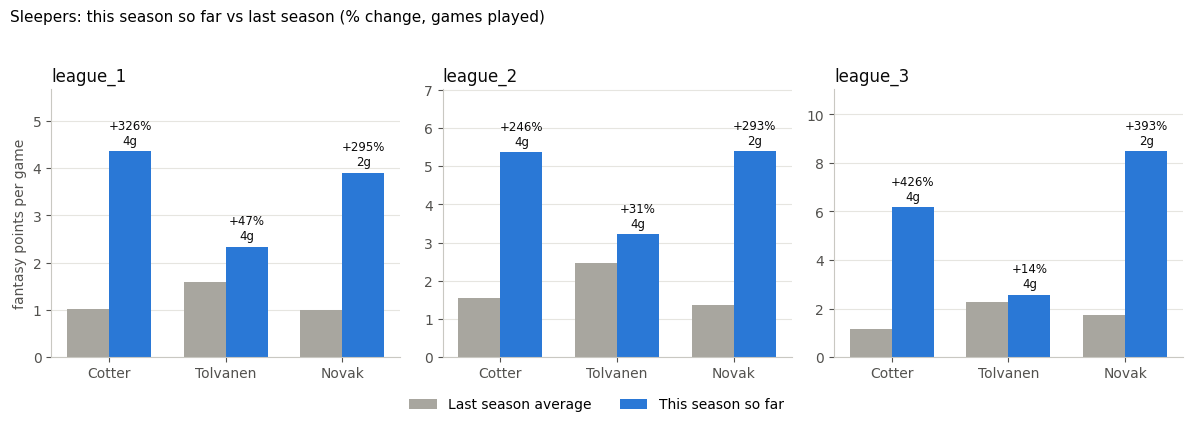

Pulling fresh game log for 8481032, 20262027
Loading game log for 8481032, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8480009, 20262027
Loading game log for 8480009, 20252026 from cache, 0.2 hours old
Pulling fresh game log for 8478438, 20262027
Loading game log for 8478438, 20252026 from cache, 0.2 hours old


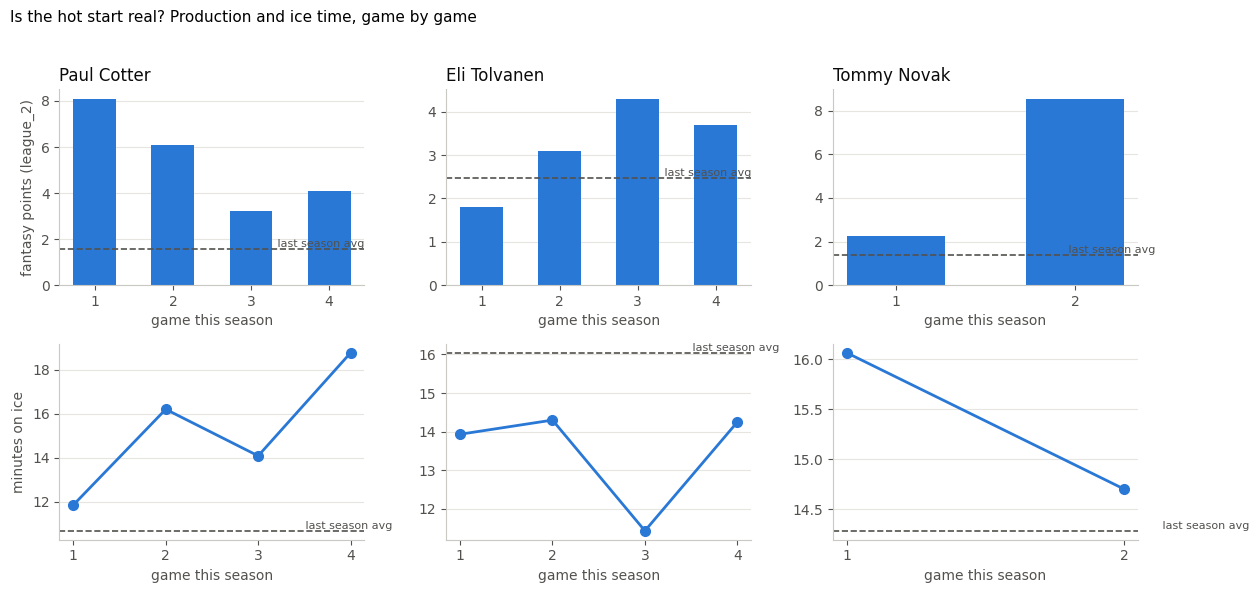

In [25]:
def plot_sleeper_bars(df):
    leagues = sorted(df["league"].unique())
    players = list(dict.fromkeys(df["player"]))
    fig, axes = plt.subplots(1, len(leagues), figsize=(4.0 * len(leagues), 4.2))
    axes = np.atleast_1d(axes)
    x = np.arange(len(players))
    w = 0.36
    for ax, league in zip(axes, leagues):
        d = df[df["league"] == league].set_index("player").loc[players]
        ax.bar(x - w/2, d["last_season_avg"], w, color=GRAY, label="Last season average")
        ax.bar(x + w/2, d["this_season_avg"], w, color=BLUE, label="This season so far")
        top = max(d["last_season_avg"].max(), d["this_season_avg"].max())
        for xi, (_, r) in zip(x, d.iterrows()):
            ax.text(xi + w/2, r["this_season_avg"] + top * 0.02, f"{r['vs_last_season']:+.0%}\n{int(r['games'])}g",
                    ha="center", va="bottom", fontsize=8.5, color=INK)
        ax.set_ylim(0, top * 1.3)
        ax.set_xticks(x)
        ax.set_xticklabels([p.split()[-1] for p in players])
        ax.set_title(league, loc="left")
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("fantasy points per game")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
    fig.suptitle("Sleepers: this season so far vs last season (% change, games played)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout(rect=(0, 0.06, 1, 0.95))
    plt.show()

plot_sleeper_bars(sleepers_w2)


def plot_sleeper_games(league="league_2"):
    """Game by game this season: fantasy points (bars) and ice time (line), with last season's average as a dashed line."""
    cfg, fmap = cfg_and_map(league, "F")
    n = len(SLEEPERS_W2)
    fig, axes = plt.subplots(2, n, figsize=(4.2 * n, 6), squeeze=False)
    for j, name in enumerate(SLEEPERS_W2):
        pid = resolve_id(name)
        cur = _scored_game_log(pid, SEASON, "F", cfg, fmap, force_refresh=True)
        last_avg = get_prior_season_stats(pid, PRIOR_SEASON, "F", cfg, fmap)[0]
        ax = axes[0, j]
        if cur is None:
            ax.set_title(f"{name}: no games yet", loc="left"); continue
        g = np.arange(1, len(cur) + 1)
        ax.bar(g, cur["fantasy_points"], color=BLUE, width=0.55)
        ax.axhline(last_avg, color=MUTED, linestyle="--", linewidth=1.2)
        ax.text(g[-1] + 0.45, last_avg, " last season avg", color=MUTED, fontsize=8, va="bottom", ha="right")
        ax.set_title(f"{name}", loc="left")
        ax.set_xticks(g)
        ax.set_xlabel("game this season")
        if j == 0:
            ax.set_ylabel(f"fantasy points ({league})")
        ax.grid(axis="x", visible=False)

        ax2 = axes[1, j]
        if "toi" in cur.columns:
            toi = cur["toi"].map(toi_minutes)
            ax2.plot(g, toi, color=BLUE, linewidth=2, marker="o", markersize=7)
            last_toi = process.loc[(process["player"] == name) & (process["season"] == "last season"), "toi_per_game"]
            if len(last_toi) and pd.notna(last_toi.iloc[0]):
                ax2.axhline(last_toi.iloc[0], color=MUTED, linestyle="--", linewidth=1.2)
                ax2.text(g[-1] + 0.45, last_toi.iloc[0], " last season avg", color=MUTED, fontsize=8, va="bottom", ha="right")
            ax2.set_xticks(g)
            ax2.set_xlabel("game this season")
            if j == 0:
                ax2.set_ylabel("minutes on ice")
        else:
            ax2.text(0.5, 0.5, "no ice time in this data", ha="center", va="center", transform=ax2.transAxes, color=MUTED)
        ax2.grid(axis="x", visible=False)
    fig.suptitle("Is the hot start real? Production and ice time, game by game", x=0.01, ha="left", fontsize=11)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

plot_sleeper_games("league_2")

In [26]:
sleepers_w2.to_csv("predictions/sleepers_week02.csv", index=False)
process.to_csv("predictions/sleepers_week02_process.csv", index=False)

## Sleeper picks (Week 2)

**A note on sample size.** Each of these is 2 to 4 games into the season.
Rostered percentages are from Yahoo as of 10/05, Cotter 28%, Novak 22%,
Tolvanen 6%.

The hot starts look different once I check how they were produced:

- **Paul Cotter (VAN)** has the clearest case. His ice time is up from 10.7
  to 15.2 minutes a game, and his shots per game have more than doubled
  (0.77 to 1.75). His 57% shooting won't last, so I expect fewer points
  than he's scoring now, but the extra role is real.
- **Eli Tolvanen (NYR)** is the weakest on the numbers. 3 goals on 6 shots
  is finishing, not volume: his shots (1.5 vs 1.8) and ice time (13.5 vs
  16.0) are both down and he has no power-play points yet. His hits and
  blocks may be the part that lasts, which counts in league 2.
- **Tommy Novak (PIT)** has only 2 games, too few to say. His ice time
  (15.4 vs 14.3) doesn't yet show a bigger role, though his 2 power-play
  points fit the PP1 idea.

What I'm tracking next week: ice time and shots for all three, and
whether Cotter and Novak keep the role I'm betting on.